Persistence in LangGraph refers to the ability to save and restore the state of any workflow which is done executing .

using this , we can store the state when it got changes at every intermediate stage . where it got changed over time . 

we can prevent Fault Tolerance . we our system crashes let's say at 5th node and this node has made some wrong changes to the state, we can restore our state at 4th node . 

we will save these values in some kind of database. and then we can restore them . 
we can create resume chat feature using this in chatbots .





This is implemented using Checkpointers and Threads:
Checkpointer: It divides the entire graph execution into check points (typically at every super-step) and saves the state's intermediate and final values at each of these points
.
Threads (thread_id): When executing a workflow, you assign a unique thread_id so that the database stores the generated state values against this specific execution session
. This allows you to fetch the exact history of a specific conversation or execution later on

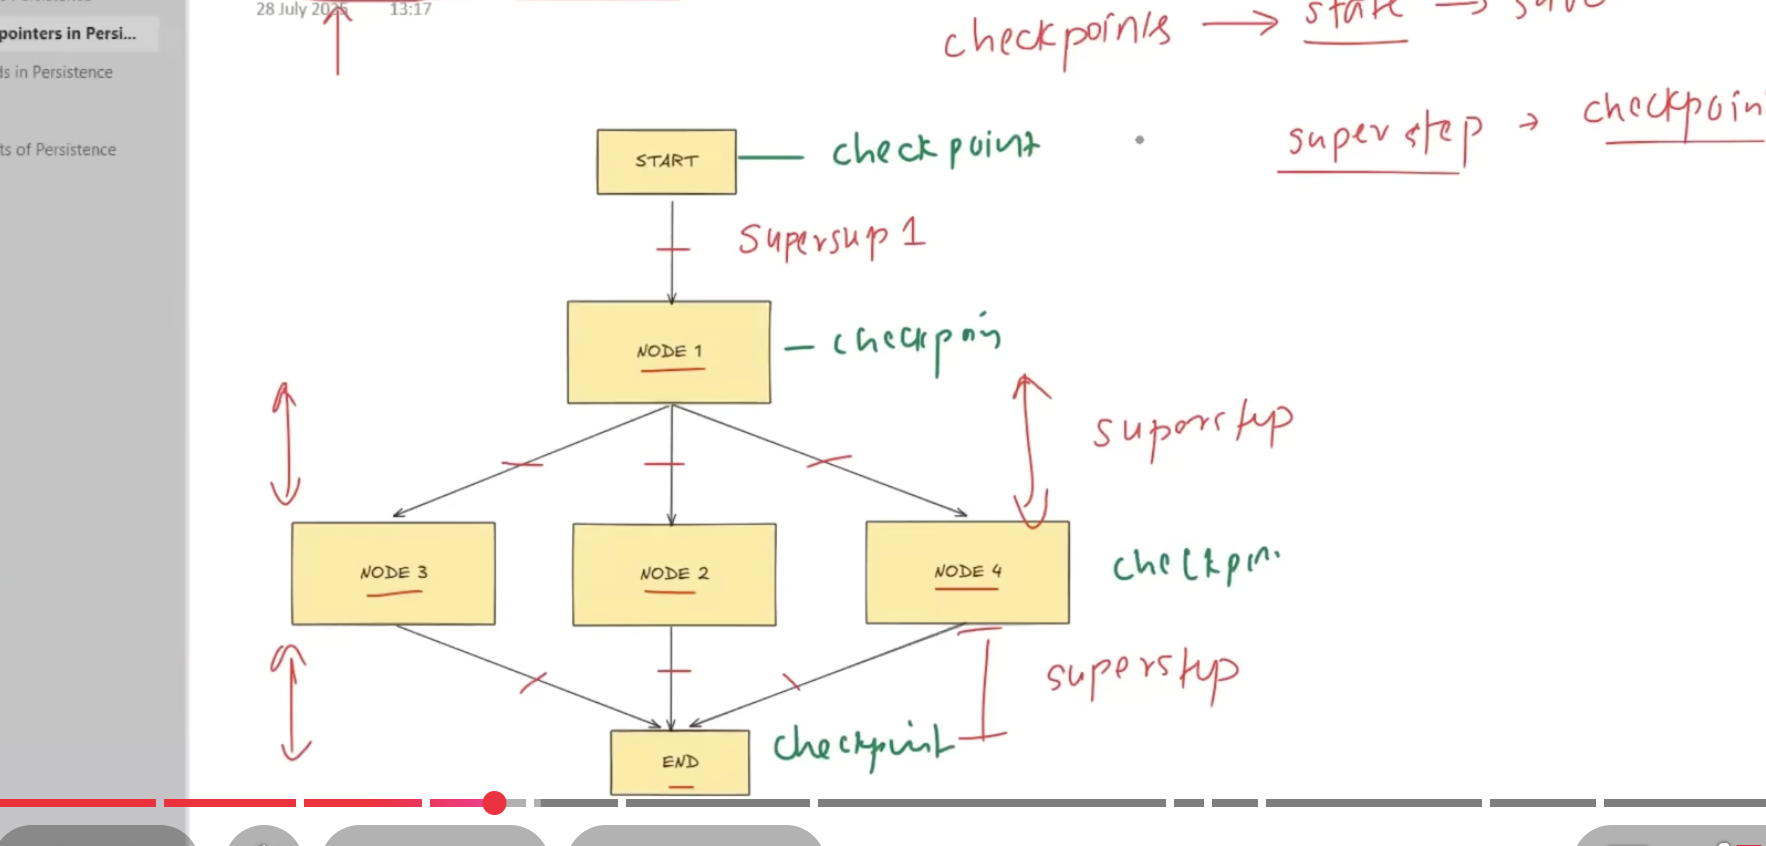

### Building a simple chat bot with CheckPoints so that we can resume 

In [43]:
from langgraph.graph import StateGraph , START , END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os 




In [44]:
load_dotenv()
model = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model = 'llama-3.3-70b-versatile')

In [45]:
class JokeState(TypedDict):
    topic : str 
    joke : str 
    explanation : str 


In [46]:
def make_joke(state : JokeState):
    topic = state['topic']
    prompt = f'give a short joke on the topic {topic}'
    response = model.invoke(prompt).content
    return {'joke' : response}

def explain_joke(state : JokeState):
    topic = state['topic']
    prompt = f'give a small explaination of this joke {state['joke']} on the topic {topic}'
    response = model.invoke(prompt).content
    return {'explanation' : response}



In [47]:
builder = StateGraph(JokeState)

builder.add_node('make_joke' , make_joke)
builder.add_node('explain_joke' ,explain_joke)

builder.add_edge(START , "make_joke")
builder.add_edge("make_joke", "explain_joke")
builder.add_edge("explain_joke", END)

# To implement persistence, you must create a checkpointer object and pass it during the graph compilation
checkpointer = MemorySaver()


workflow = builder.compile(checkpointer= checkpointer)

In [48]:

# When executing the workflow, you must provide a configuration containing the thread_id
config = {'configurable' : {"thread_id" : '1'}}
workflow.invoke({'topic' : 'Pizza'} , config = config)



{'topic': 'Pizza',
 'joke': 'Why was the pizza in a bad mood. Because it was feeling crusty.',
 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling crusty" is a play on words. In this joke, "crusty" has a double meaning. In the context of pizza, the crust refers to the outer layer of the pizza. However, "feeling crusty" is also an idiomatic expression that means being irritable or in a bad mood. The joke relies on this wordplay to create a humorous connection between the pizza\'s physical crust and its emotional state, making it a lighthearted and amusing pun related to pizza.'}

In [49]:
# Fetch the final state of the execution 
final_state = workflow.get_state(config=config)
print(final_state.values)

{'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood. Because it was feeling crusty.', 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling crusty" is a play on words. In this joke, "crusty" has a double meaning. In the context of pizza, the crust refers to the outer layer of the pizza. However, "feeling crusty" is also an idiomatic expression that means being irritable or in a bad mood. The joke relies on this wordplay to create a humorous connection between the pizza\'s physical crust and its emotional state, making it a lighthearted and amusing pun related to pizza.'}


In [50]:
# Fetch the entire history (all intermediate checkpoints) 
list(workflow.get_state_history(config=config ))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood. Because it was feeling crusty.', 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling crusty" is a play on words. In this joke, "crusty" has a double meaning. In the context of pizza, the crust refers to the outer layer of the pizza. However, "feeling crusty" is also an idiomatic expression that means being irritable or in a bad mood. The joke relies on this wordplay to create a humorous connection between the pizza\'s physical crust and its emotional state, making it a lighthearted and amusing pun related to pizza.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13273f-66e4-672e-8002-60e2a8e473a6'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-07T11:21:46.224596+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13273f-5ff7-68b2-8001-bf8def9fb179'}},

## Advanced Features enabled by persistence : 
A. Fault Tolerance (Resuming from Crashes) If a workflow crashes at a specific node (e.g., due to a server or API failure), persistence allows you to resume exactly where it stopped instead of starting over
You do this by passing None as the input while invoking the graph with the same thread_id


In [ ]:

workflow.invoke(None, config)

{'topic': 'Pizza',
 'joke': 'Why was the pizza in a bad mood? \nBecause it was feeling a little crusty.',
 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words related to pizza. In this joke, "crusty" has a double meaning: \n\n1. A pizza crust is the outer layer of the pizza, typically made from baked dough.\n2. "Feeling crusty" is also an idiomatic expression that means being irritable or in a bad mood.\n\nSo, the joke is making a pun on the word "crusty" to create a humorous connection between the pizza\'s physical crust and its emotional state, implying that the pizza is in a bad mood because it\'s feeling a little irritable, or "crusty".'}

## B. Time Travel (Replaying and Updating) 
Time travel allows you to go back to a specific checkpoint in the past and replay the execution from that exact point, which is highly useful for debugging complex workflows
. You can also update the state variable at that checkpoint (e.g., changing the topic from "Pizza" to "Samosa") and fork a new execution path

In [52]:
# Find a specific checkpoint ID from the history where the topic was received but joke wasn't generated yet [24]

checkpoint_id = "1f13273f-5b54-6abc-8000-a8ad445163ab"
# Create a new config containing both thread_id and checkpoint_id
config_with_checkpoint = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": checkpoint_id,
        'checkpoint_ns' :'default'
    }
}
# UPDATE STATE: Change the topic from Pizza to Samosa at that specific checkpoint
workflow.update_state(config_with_checkpoint, {"topic": "Samosa"})

# REPLAY: Invoke the workflow from the newly updated branch [26]
# Notice we pass None as the input because the state is already loaded from the checkpoint [26]
workflow.invoke(None, config_with_checkpoint)

ValueError: Subgraph default not found